# BÀI TẬP BUỔI 5: THUẬT TOÁN K-NEAREST NEIGHBORS (K-NN)
## MÔN: HỌC MÁY VÀ ỨNG DỤNG HỌC MÁY
### Sinh viên: Nguyễn Trung Kiên | MSSV: 102230023 | Khoa Công nghệ Thông tin - Trường Đại học Bách khoa, ĐH Đà Nẵng
---
> **Phương châm học tập:** *"Hiểu thấu bản chất mêtric không gian và thuật toán từ Scratch trước khi gọi thư viện. Phân tích sâu sắc ranh giới quyết định và sự đánh đổi Bias-Variance."*

### Mục tiêu bài tập (Theo tài liệu `KNN_exercises.pdf` - Exercise 01):
1. **Số hóa & Khám phá Dữ liệu:** Khai thác tập dữ liệu 2D gồm **31 điểm huấn luyện** thuộc 4 lớp: $\mathcal{C} = \{\text{red triangle}, \text{blue square}, \text{green star}, \text{black heart}\}$ và **6 điểm kiểm thử chưa gán nhãn** ($A, B, C, D, E, F$).
2. **Câu a - Tính toán từng bước:** Lập bảng khoảng cách và phân lớp cho cả 6 điểm dưới **6 cấu hình** ($k \in \{4, 5, 6\}$ với khoảng cách Euclidean và Manhattan).
3. **Câu b - Báo cáo phân tích chuyên sâu:** Khảo sát tác động của kích thước láng giềng $k$, sự khác biệt hình học giữa Euclidean và Manhattan, cùng hiện tượng hòa phiếu (Tie-breaking).
4. **Câu c - Cài đặt KNN Scratch:** Viết chương trình Python thuần (không dùng scikit-learn) có hiển thị chi tiết bảng láng giềng, tỷ lệ phiếu bầu và chạy thực nghiệm minh họa cho điểm $E$ với $k = 5$.

## 1. Khai báo các thư viện cần thiết
Sử dụng các thư viện chuẩn trong tính toán khoa học: `numpy`, `matplotlib`, `math`, `collections.Counter`.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import Counter
from typing import List, Tuple, Dict, Any

print("Đã nạp thành công tất cả các thư viện cần thiết!")

Đã nạp thành công tất cả các thư viện cần thiết!


## 2. Số hóa Không gian Dữ liệu từ Hình 1 (Figure 1)
Trích xuất chính xác tọa độ của 31 điểm huấn luyện và 6 điểm cần phân loại trên lưới tọa độ $10 \times 10$.

In [2]:
# Tập 31 điểm huấn luyện
TRAINING_DATA = [
    # y = 9
    (1, 9, 'red triangle'), (3, 9, 'red triangle'), (9, 9, 'blue square'),
    # y = 8
    (4, 8, 'green star'), (7, 8, 'blue square'),
    # y = 7
    (1, 7, 'blue square'), (3, 7, 'blue square'), (4, 7, 'red triangle'), (8, 7, 'green star'),
    # y = 5
    (2, 5, 'black heart'), (3, 5, 'black heart'), (4, 5, 'black heart'),
    (6, 5, 'red triangle'), (8, 5, 'blue square'),
    # y = 4
    (2, 4, 'red triangle'), (4, 4, 'green star'),
    # y = 3
    (1, 3, 'black heart'), (3, 3, 'black heart'), (5, 3, 'blue square'), (8, 3, 'blue square'),
    # y = 2
    (1, 2, 'red triangle'), (2, 2, 'black heart'), (4, 2, 'black heart'),
    (6, 2, 'red triangle'), (8, 2, 'green star'), (9, 2, 'blue square'),
    # y = 1
    (1, 1, 'black heart'), (2, 1, 'green star'), (3, 1, 'red triangle'),
    (5, 1, 'black heart'), (8, 1, 'blue square'),
]

# 6 điểm kiểm thử cần phân loại A, B, C, D, E, F
UNLABELED_POINTS = {
    'A': (2, 8),
    'B': (6, 7),
    'C': (7, 5),
    'D': (2, 3),
    'E': (7, 2),
    'F': (4, 1)
}

print(f"Tổng số điểm huấn luyện: {len(TRAINING_DATA)} điểm.")
counts = Counter([p[2] for p in TRAINING_DATA])
print("Phân phối các lớp trong tập huấn luyện:")
for cls, cnt in counts.items():
    print(f"  • {cls}: {cnt} điểm")

Tổng số điểm huấn luyện: 31 điểm.
Phân phối các lớp trong tập huấn luyện:
  • red triangle: 8 điểm
  • blue square: 9 điểm
  • green star: 5 điểm
  • black heart: 9 điểm


### Trực quan hóa Không gian Dữ liệu Figure 1
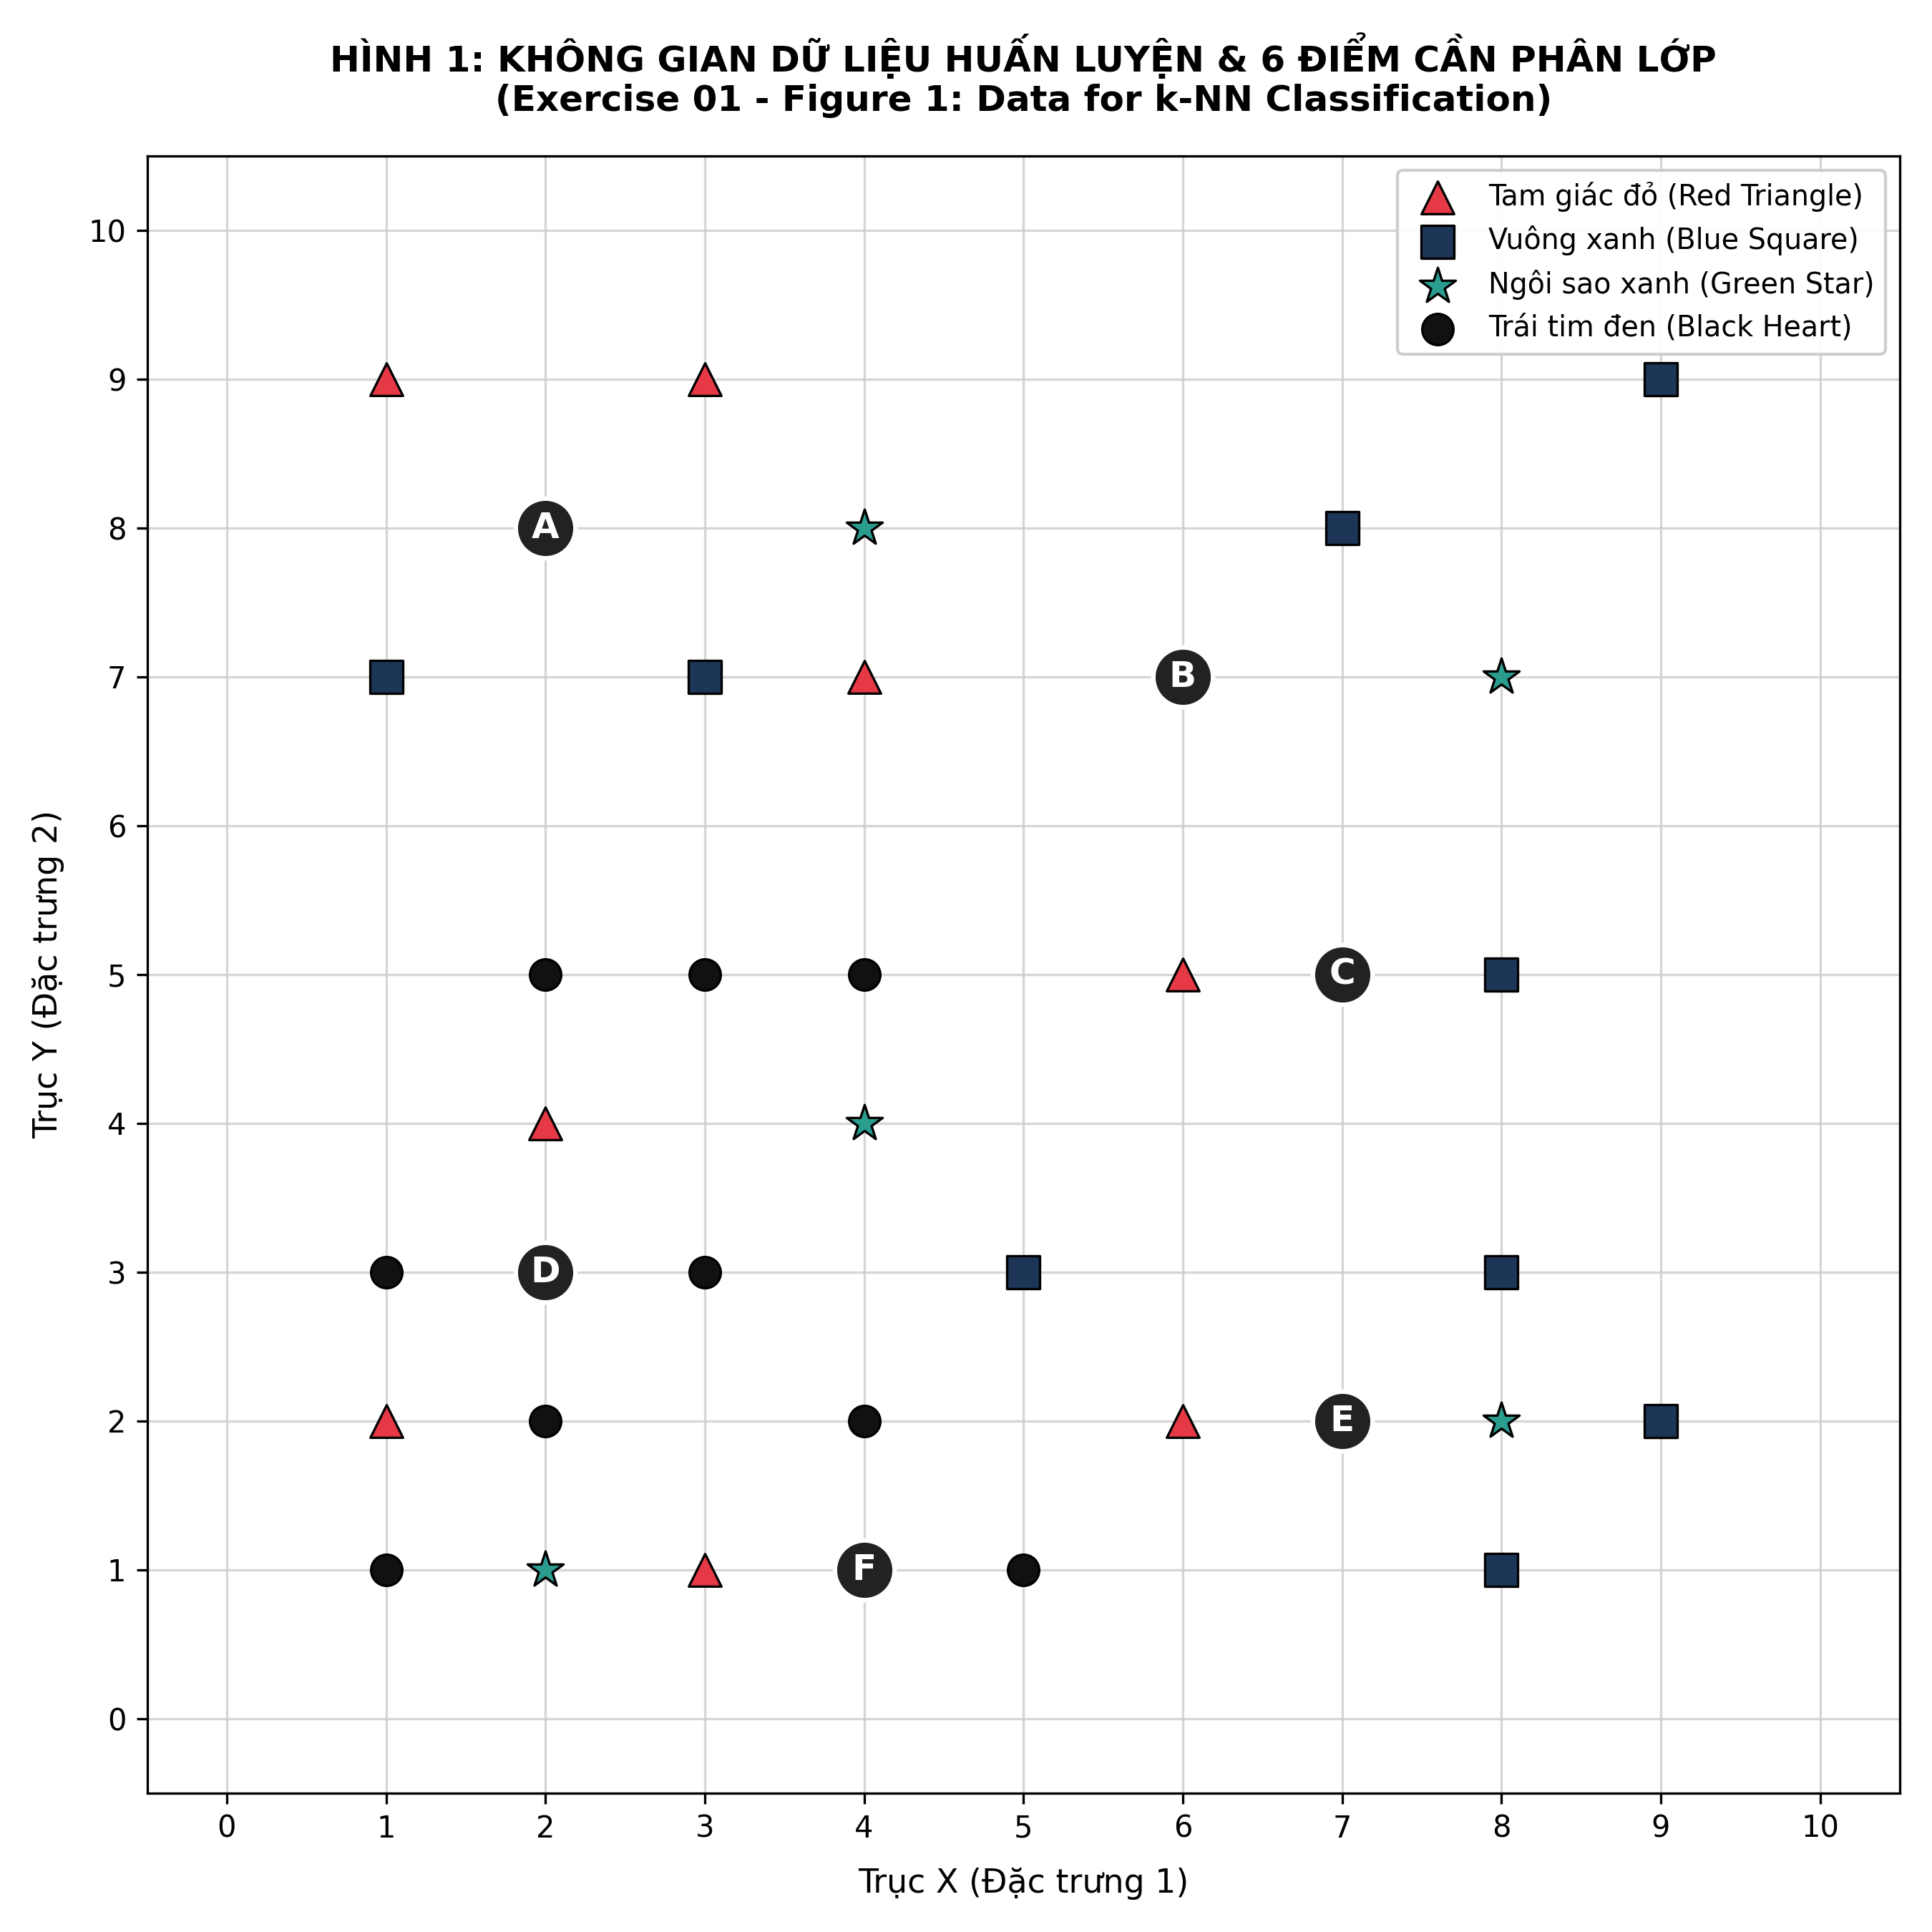

## 3. Cài đặt Thuật toán KNN từ Scratch (Không dùng Scikit-Learn)
Hàm tính khoảng cách Euclidean ($L_2$) và Manhattan ($L_1$):
- Euclidean: $d_E(p, q) = \sqrt{(x_p - x_q)^2 + (y_p - y_q)^2}$
- Manhattan: $d_M(p, q) = |x_p - x_q| + |y_p - y_q|$

In [3]:
def calculate_distance(p1: Tuple[float, float], p2: Tuple[float, float], metric: str = 'euclidean') -> float:
    dx = abs(p1[0] - p2[0])
    dy = abs(p1[1] - p2[1])
    if metric.lower() == 'euclidean':
        return math.sqrt(dx ** 2 + dy ** 2)
    elif metric.lower() == 'manhattan':
        return dx + dy
    else:
        raise ValueError(f"Độ đo '{metric}' không hợp lệ.")

class KNNClassifierScratch:
    def __init__(self, training_data: List[Tuple[float, float, str]]):
        self.training_data = training_data

    def predict(self, target_point: Tuple[float, float], k: int = 5, metric: str = 'euclidean', verbose: bool = False):
        neighbor_table = []
        for x, y, label in self.training_data:
            d = calculate_distance(target_point, (x, y), metric=metric)
            neighbor_table.append({'coord': (x, y), 'label': label, 'distance': d})
        
        # Sắp xếp ổn định theo khoảng cách tăng dần
        neighbor_table.sort(key=lambda item: (round(item['distance'], 6), item['coord']))
        k_nearest = neighbor_table[:k]
        
        labels = [item['label'] for item in k_nearest]
        vote_counts = Counter(labels)
        max_votes = max(vote_counts.values())
        top_classes = [cls for cls, cnt in vote_counts.items() if cnt == max_votes]
        is_tie = len(top_classes) > 1
        predicted_label = top_classes[0] if not is_tie else "TIE: " + "/".join(top_classes)
        
        if verbose:
            print(f"🎯 ĐIỂM MỤC TIÊU: {target_point} | k = {k} | Độ đo: {metric.upper()}")
            print(f"{'Hạng':<6}{'Tọa độ':<16}{'Khoảng cách':<14}{'Nhãn thực tế':<15}")
            for i, it in enumerate(k_nearest, 1):
                print(f"{i:<6}{str(it['coord']):<16}{it['distance']:<14.4f}{it['label']:<15}")
            print(f"=> Phiếu bầu: {dict(vote_counts)} | Kết quả: {predicted_label}\n")
            
        return {
            'k_nearest': k_nearest,
            'vote_counts': dict(vote_counts),
            'top_classes': top_classes,
            'is_tie': is_tie,
            'predicted_label': predicted_label
        }

## 4. Lời giải Câu a: Bảng Tính toán & Phân lớp Chi tiết 6 Điểm qua 6 Cấu hình
Thực thi duyệt qua toàn bộ 6 điểm kiểm thử ($A, B, C, D, E, F$) trên 6 cấu hình độc lập.

In [4]:
clf = KNNClassifierScratch(TRAINING_DATA)
print("=== BẢNG TỔNG HỢP KẾT QUẢ PHÂN LỚP QUA 6 CẤU HÌNH ===")
for name, coord in UNLABELED_POINTS.items():
    print(f"Điểm {name} {coord}:")
    for metric in ['euclidean', 'manhattan']:
        sub_res = []
        for k in [4, 5, 6]:
            res = clf.predict(coord, k=k, metric=metric, verbose=False)
            sub_res.append(f"k={k} -> {res['predicted_label']}")
        print(f"  • {metric.capitalize()}: {' | '.join(sub_res)}")

=== BẢNG TỔNG HỢP KẾT QUẢ PHÂN LỚP QUA 6 CẤU HÌNH ===
Điểm A (2, 8):
  • Euclidean: k=4 -> TIE: blue square/red triangle | k=5 -> TIE: blue square/red triangle | k=6 -> red triangle
  • Manhattan: k=4 -> TIE: blue square/red triangle | k=5 -> TIE: blue square/red triangle | k=6 -> TIE: blue square/red triangle
Điểm B (6, 7):
  • Euclidean: k=4 -> red triangle | k=5 -> TIE: red triangle/green star | k=6 -> TIE: red triangle/green star
  • Manhattan: k=4 -> red triangle | k=5 -> TIE: red triangle/blue square | k=6 -> TIE: red triangle/blue square/green star
Điểm C (7, 5):
  • Euclidean: k=4 -> blue square | k=5 -> blue square | k=6 -> blue square
  • Manhattan: k=4 -> blue square | k=5 -> blue square | k=6 -> blue square
Điểm D (2, 3):
  • Euclidean: k=4 -> black heart | k=5 -> black heart | k=6 -> black heart
  • Manhattan: k=4 -> black heart | k=5 -> black heart | k=6 -> black heart
Điểm E (7, 2):
  • Euclidean: k=4 -> blue square | k=5 -> blue square | k=6 -> blue square
  • Manhattan

### Bảng Ma trận Tổng hợp Kết quả Phân loại (Consolidated Matrix)
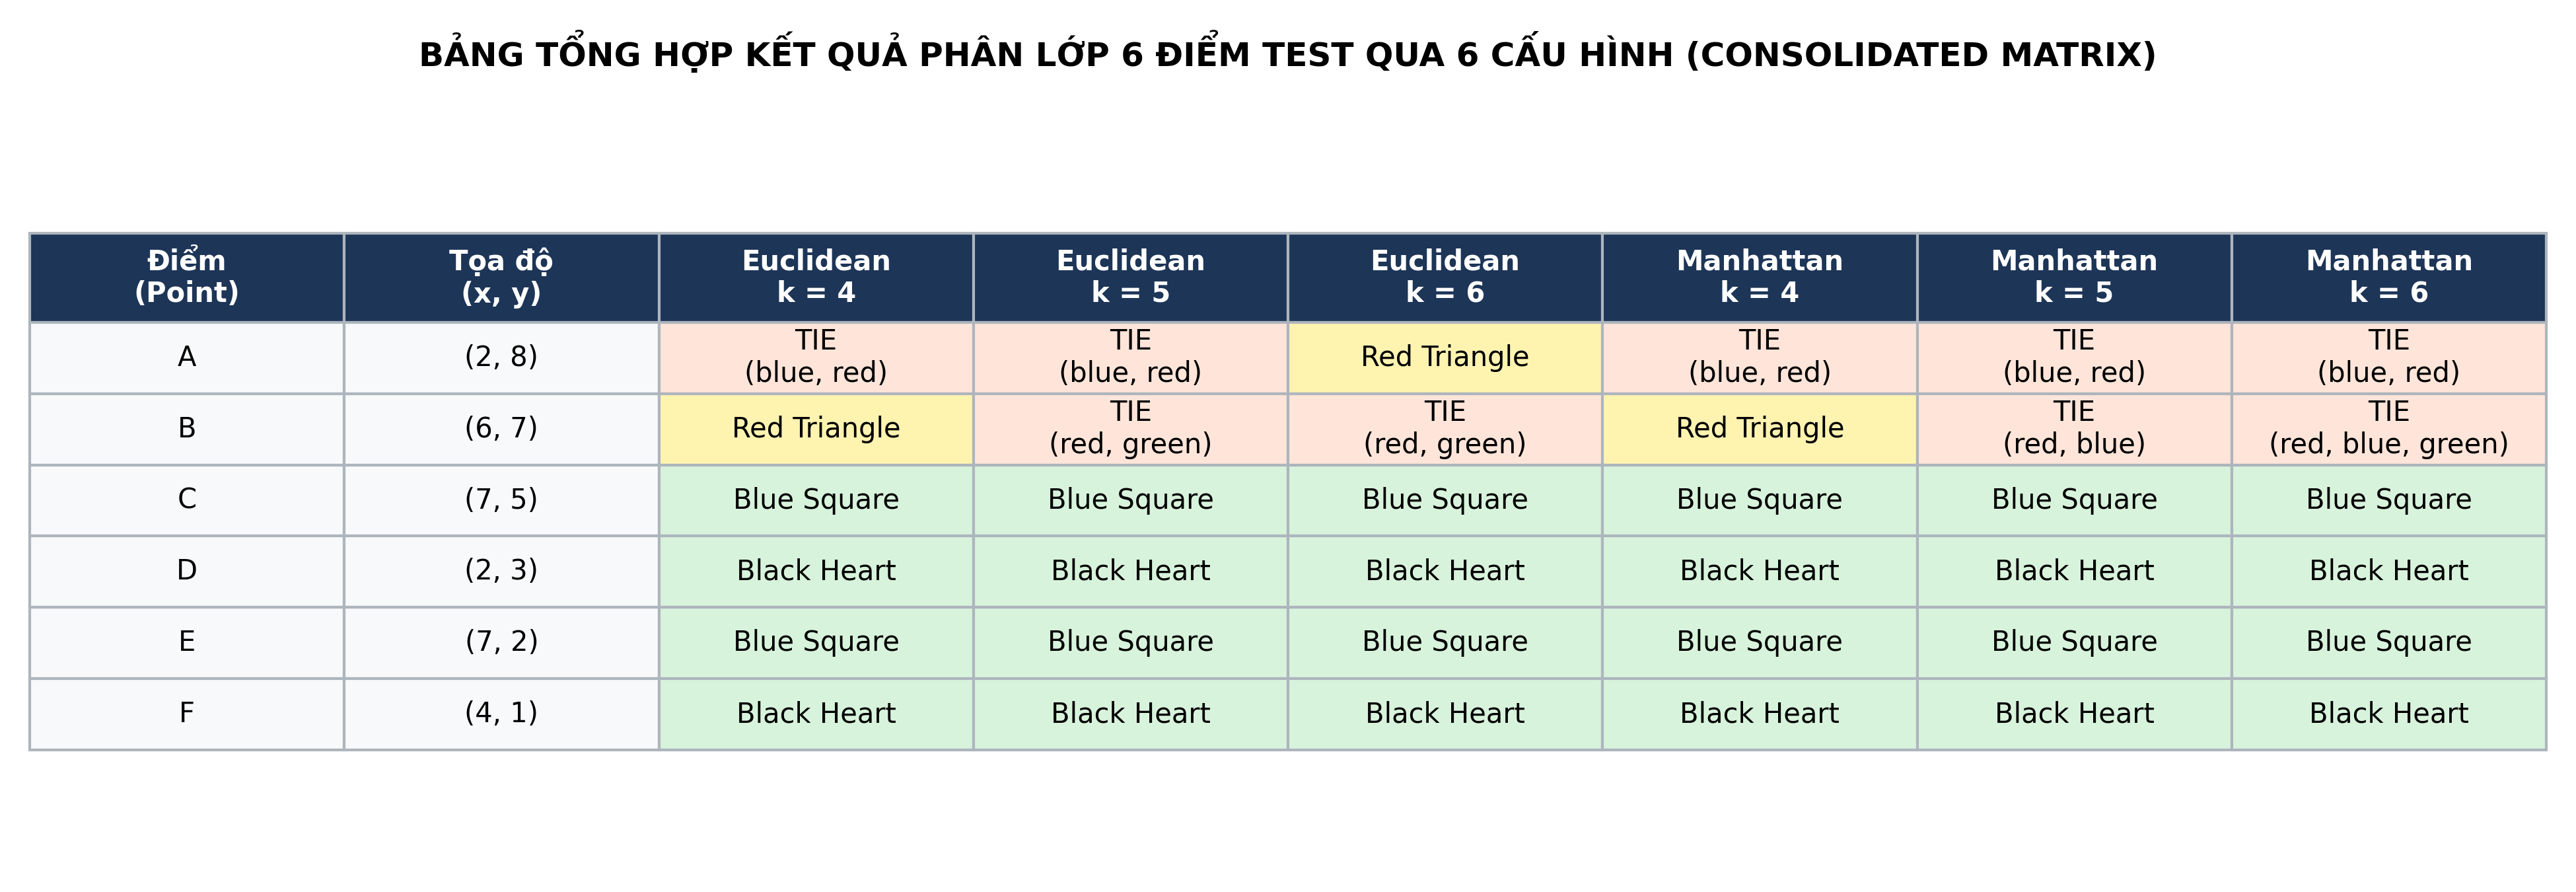

| Điểm | Tọa độ | Euclidean $k=4$ | Euclidean $k=5$ | Euclidean $k=6$ | Manhattan $k=4$ | Manhattan $k=5$ | Manhattan $k=6$ |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **A** | $(2, 8)$ | *Tie (Blue/Red)* | *Tie (Blue/Red)* | **Red Triangle** | *Tie (Blue/Red)* | *Tie (Blue/Red)* | *Tie (Blue/Red)* |
| **B** | $(6, 7)$ | **Red Triangle** | *Tie (Red/Green)* | *Tie (Red/Green)* | **Red Triangle** | *Tie (Red/Blue)* | *Tie (3-way)* |
| **C** | $(7, 5)$ | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** |
| **D** | $(2, 3)$ | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** |
| **E** | $(7, 2)$ | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** |
| **F** | $(4, 1)$ | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** |

## 5. Lời giải Câu b: Báo cáo Phân tích So sánh Toàn diện (Comparative Analysis)

### 5.1. Tác động của việc thay đổi kích thước láng giềng $k$ ($k = 4, 5, 6$)
1. **Tính bất biến tại các vùng cụm mật độ cao (Dense Core Points):**
   - Các điểm $C(7, 5)$, $D(2, 3)$, $E(7, 2)$ và $F(4, 1)$ hoàn toàn **không đổi nhãn dự đoán** khi $k$ tăng từ 4 lên 6. Lý do: mật độ các điểm cùng lớp xung quanh chúng áp đảo hoàn toàn.
2. **Hiện tượng bất ổn định tại vùng biên giới phân lớp (Boundary Ambiguity):**
   - Điểm $A(2, 8)$: Nằm chính giữa 2 cụm Red Triangle (phía trên) và Blue Square (phía dưới). Tại $k=4$ và $k=5$, số phiếu luôn hòa $2 - 2$. Đến $k=6$ trong Euclidean, việc mở rộng bán kính thu nạp thêm điểm $(4, 7)$ (Red Triangle) giúp lớp này giành chiến thắng.
   - Điểm $B(6, 7)$: Với $k=4$, Red Triangle chiếm ưu thế ($2$ phiếu). Nhưng khi mở rộng lên $k=5, 6$, các láng giềng khác (Green Star, Blue Square) xuất hiện làm tỷ lệ phiếu bị phân tán và dẫn đến hòa phiếu.
   - **Kết luận:** Số $k$ chẵn ($k=4, 6$) làm tăng nguy cơ hòa phiếu rõ rệt. Tuy nhiên, ở bài toán 4 lớp, $k=5$ lẻ vẫn có thể hòa phiếu nếu 2 lớp dẫn đầu cùng đạt $2$ phiếu.

### 5.2. Tác động của độ đo khoảng cách (Euclidean vs. Manhattan)
1. **Đường đẳng cự (Isometric Shape):**
   - Euclidean đo đường chim bay $\rightarrow$ hình đẳng cự là **hình tròn** $\sum (x_i - y_i)^2 = R^2$.
   - Manhattan đo đường bàn cờ (taxi-cab) $\rightarrow$ hình đẳng cự là **hình thoi (Diamond)** nghiêng $45^\circ$ $|x_1 - x_2| + |y_1 - y_2| = R$.
2. **Tác động lên việc xếp hạng láng giềng:**
   - Một điểm nằm chéo $(1, 1)$ có khoảng cách Euclidean là $\sqrt{2} \approx 1.414 < 2.0$, nhưng có khoảng cách Manhattan là $1 + 1 = 2.0$, ngang bằng với điểm thẳng hàng $(2, 0)$. Do đó, Manhattan tạo ra rất nhiều láng giềng đồng hạng khoảng cách, làm tăng khả năng hòa phiếu ngẫu nhiên.

### Ma trận Ranh giới Quyết định (Decision Boundaries) qua 6 Cấu hình
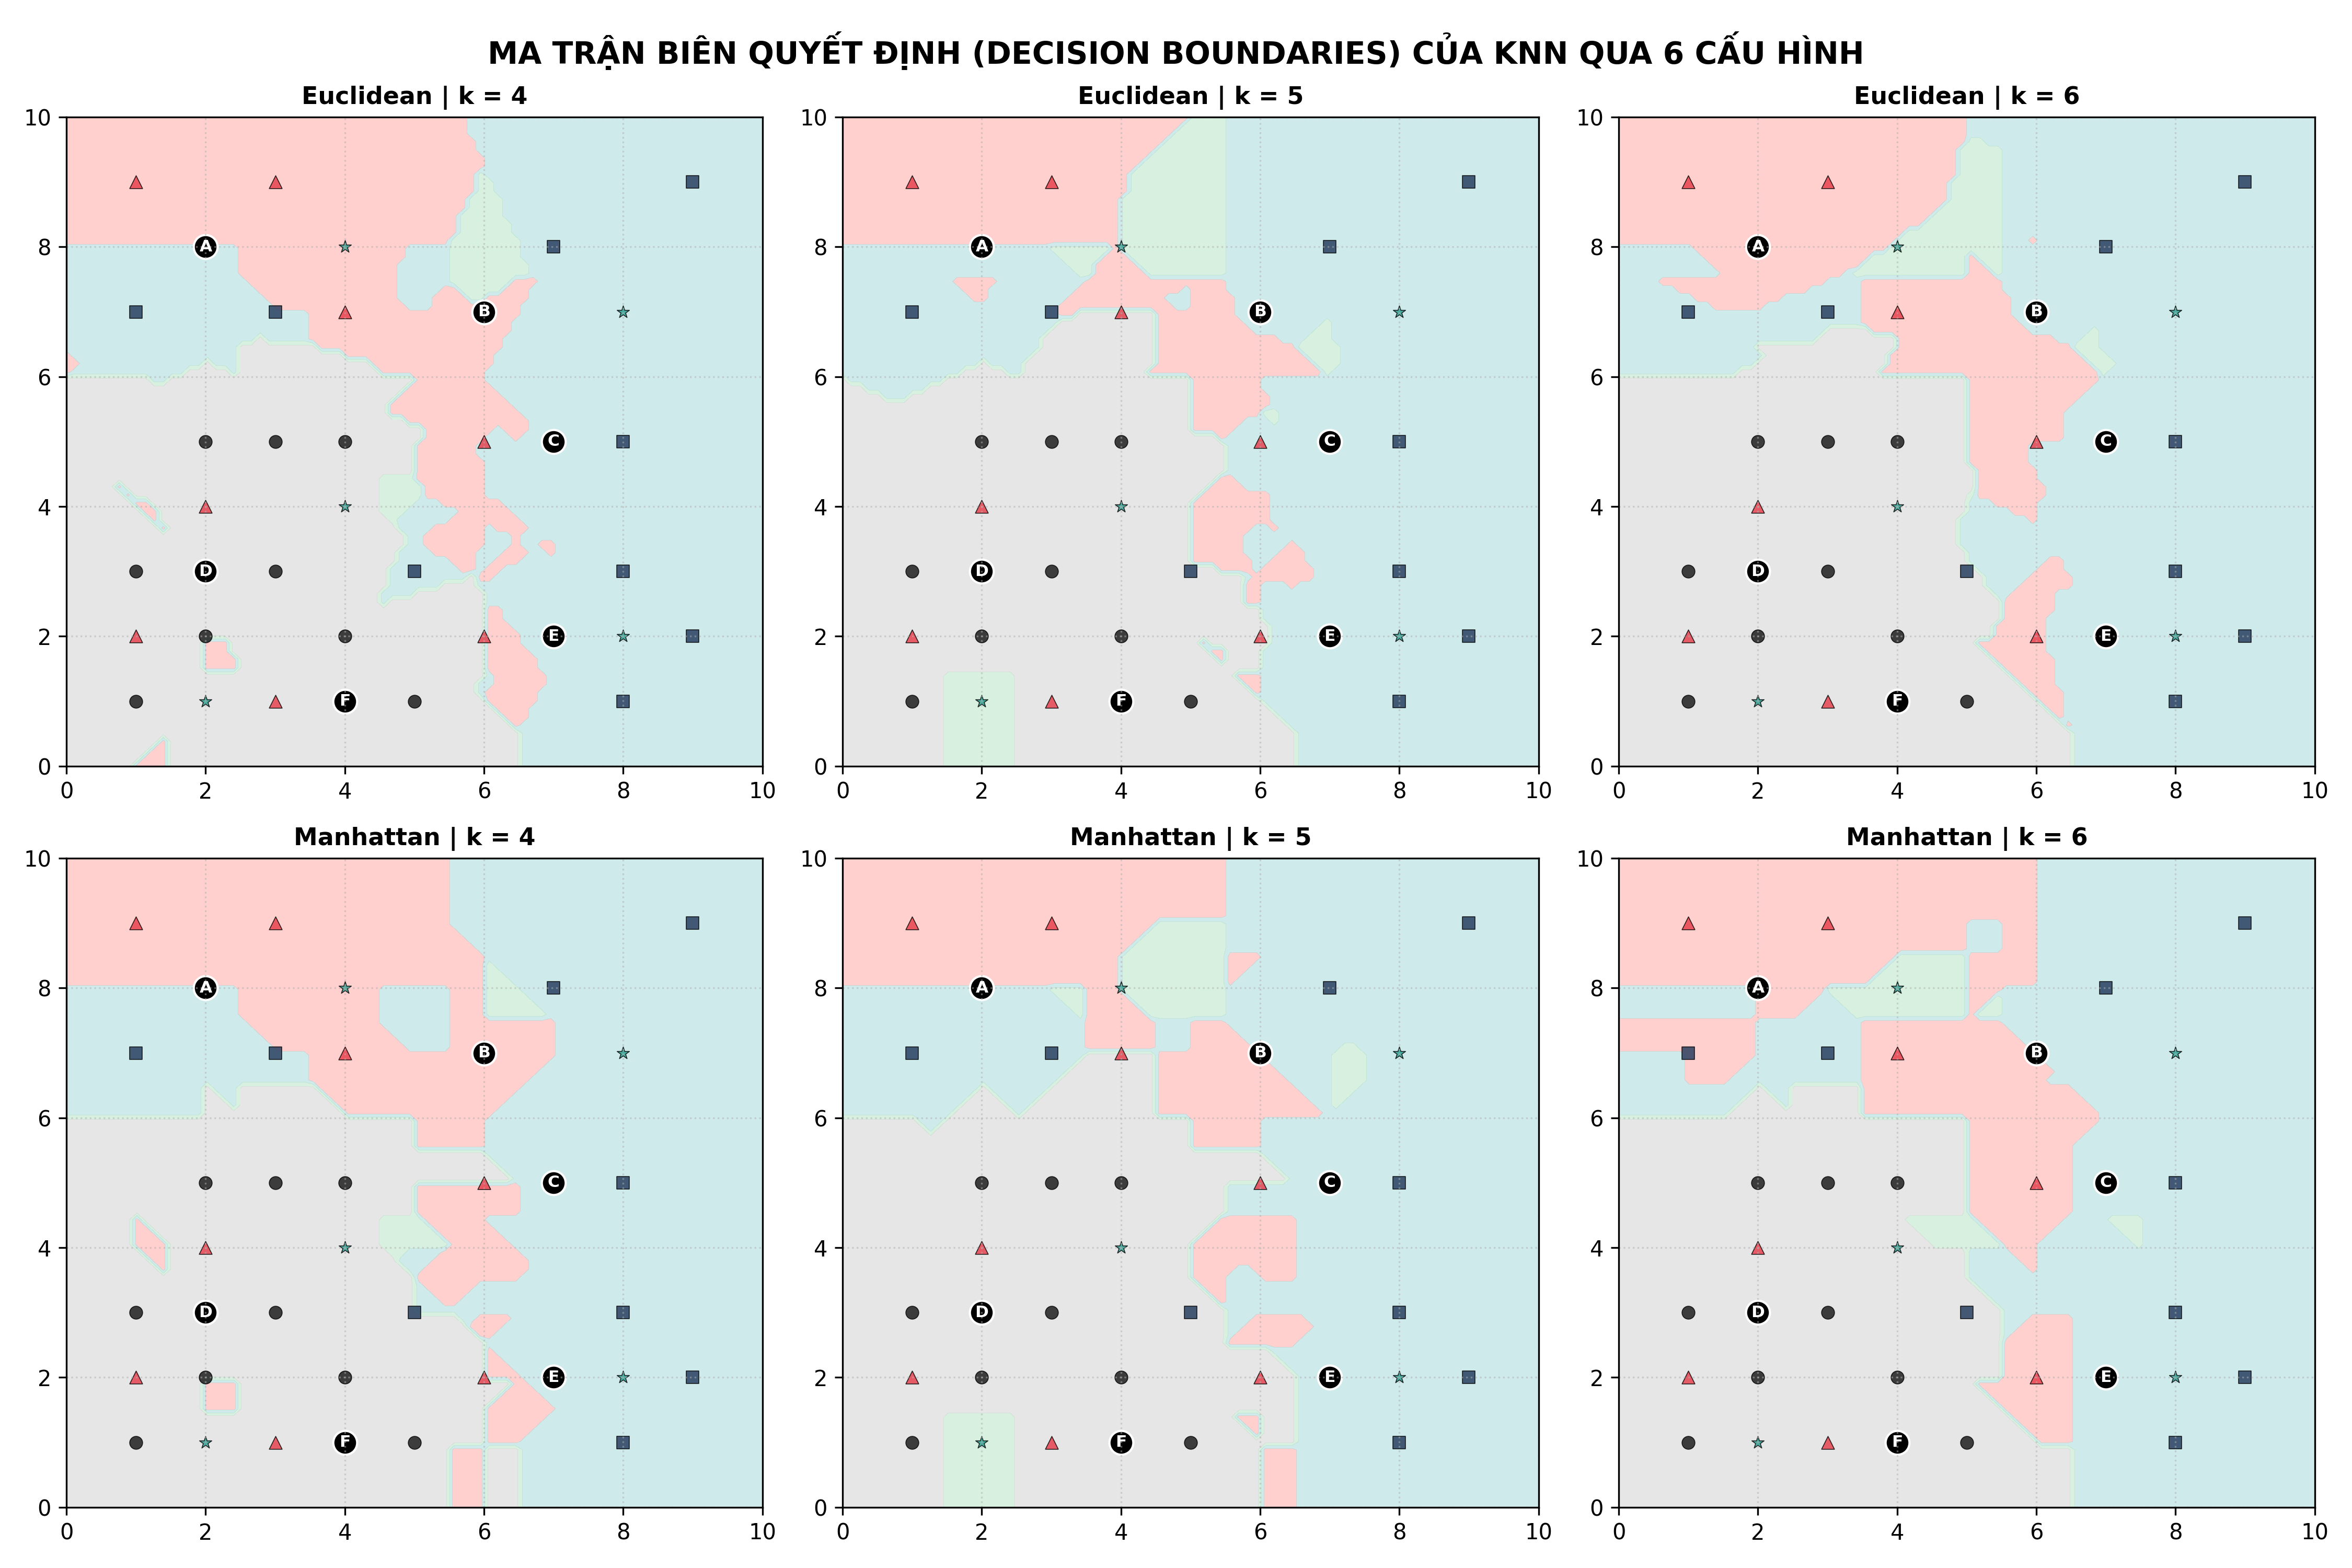

## 6. Lời giải Câu c: Minh họa Thực nghiệm Điểm E với k = 5
Yêu cầu đề bài: Thực thi và in ra console chi tiết các bước tính toán trung gian cho điểm $E = (7, 2)$ với $k = 5$ dưới cả 2 độ đo Euclidean và Manhattan.

In [5]:
print("🚀 THỰC THI DEMO MINH HỌA CHO ĐIỂM E (7, 2) VỚI K = 5:\n")
target_e = UNLABELED_POINTS['E']
clf.predict(target_e, k=5, metric='euclidean', verbose=True)
clf.predict(target_e, k=5, metric='manhattan', verbose=True)

🚀 THỰC THI DEMO MINH HỌA CHO ĐIỂM E (7, 2) VỚI K = 5:

🎯 ĐIỂM MỤC TIÊU: (7, 2) | k = 5 | Độ đo: EUCLIDEAN
Hạng  Tọa độ          Khoảng cách   Nhãn thực tế   
1     (6, 2)          1.0000        red triangle   
2     (8, 2)          1.0000        green star     
3     (8, 1)          1.4142        blue square    
4     (8, 3)          1.4142        blue square    
5     (9, 2)          2.0000        blue square    
=> Phiếu bầu: {'red triangle': 1, 'green star': 1, 'blue square': 3} | Kết quả: blue square

🎯 ĐIỂM MỤC TIÊU: (7, 2) | k = 5 | Độ đo: MANHATTAN
Hạng  Tọa độ          Khoảng cách   Nhãn thực tế   
1     (6, 2)          1.0000        red triangle   
2     (8, 2)          1.0000        green star     
3     (8, 1)          2.0000        blue square    
4     (8, 3)          2.0000        blue square    
5     (9, 2)          2.0000        blue square    
=> Phiếu bầu: {'red triangle': 1, 'green star': 1, 'blue square': 3} | Kết quả: blue square


### Trực quan hóa Hình học Bán kính Lân cận Điểm E (Hình tròn vs Hình thoi)
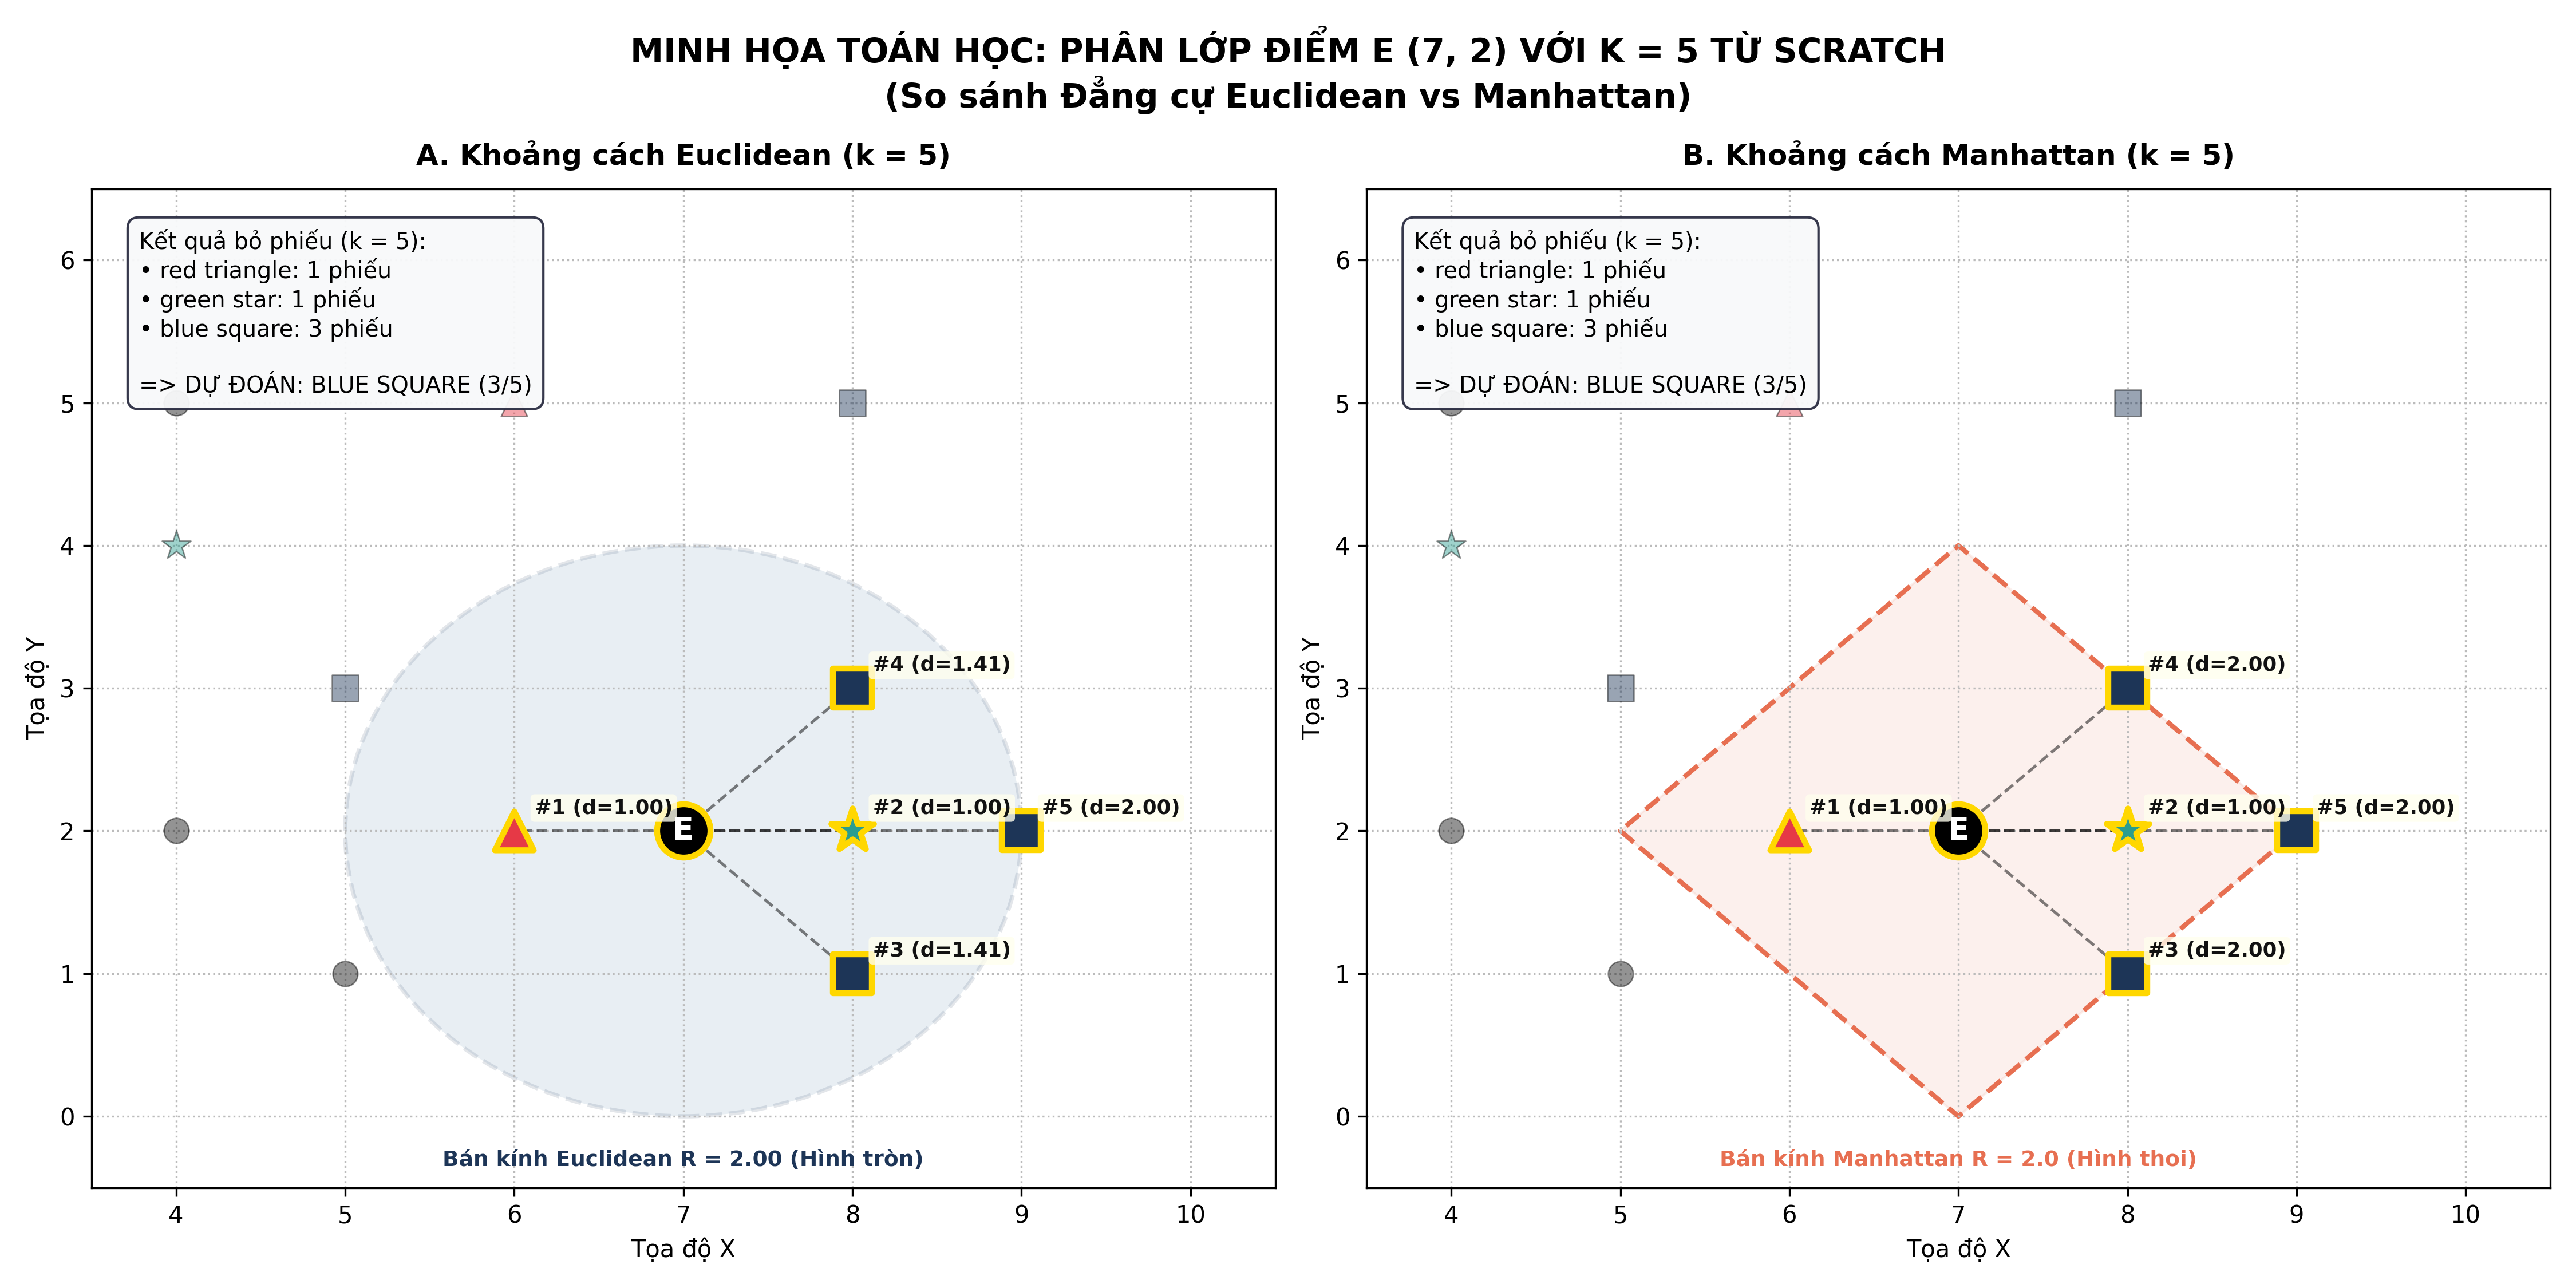

## 7. Tổng kết & Bài học Kỹ nghệ (Engineering Takeaways)

1. **Bản chất Lazy Learner:** Thuật toán KNN không tốn chi phí huấn luyện ($O(1)$), nhưng độ phức tạp trong pha suy luận là $O(N \cdot D)$ cho mỗi điểm truy vấn. Khi dữ liệu lớn, bắt buộc phải dùng các cấu trúc không gian như KD-Tree, Ball-Tree hoặc FAISS.
2. **Quy tắc chọn $k$:** Tránh chọn $k$ chẵn cho bài toán phân lớp nhị phân để loại bỏ hoàn toàn khả năng hòa phiếu. Với bài toán đa lớp, nên kết hợp cơ chế **Distance-weighted Voting** ($w_i = \frac{1}{d_i}$) thay vì chỉ dùng Majority Voting thông thường.
3. **Tầm quan trọng của Chuẩn hóa (Feature Scaling):** Cả Euclidean và Manhattan đều dựa trên khoảng cách tuyệt đối. Nếu hai trục $X$ và $Y$ có đơn vị khác nhau (ví dụ: mét và milimét), khoảng cách sẽ bị biến dạng hoàn toàn nếu không dùng `StandardScaler`.